In [2]:
import os
from pathlib import Path
import sys
import numpy as np
import scvelo as scv

In [3]:
notebook_dir = os.getcwd()
notebook_dir

'c:\\Users\\OmerCagatayTalikaci\\Desktop\\github\\STVelo\\notebooks\\analysis\\noise_effects'

In [4]:
Path(notebook_dir).parents[3]

WindowsPath('c:/Users/OmerCagatayTalikaci/Desktop/github')

In [5]:
os.chdir(Path(notebook_dir).parents[3])

In [6]:
stvelo_path = os.path.join(os.getcwd(),'STVelo','stvelo')

In [7]:
import sys  
sys.path.insert(1,stvelo_path)
from pipelines.simulation_3ode_class import Simulation3ODE
from pipelines.metrics import *
from pipelines.preprocessing import Preprocessing
from pipelines.compute_velocity import Velocities
from pipelines.utils import proportions_nuc_cyto

In [8]:
config_simulation = {'parameters':{ 'n_obs':800,
    'n_vars':300,
    'alpha':None,
    'beta':None,
    'nu' :None,
    'gamma':None,
    'alpha_':0,
    't_max':20,
    'noise_model':"normal",
    'noise_level':3,
    }, 

    'options': {'generate_parameters':True,
                'generate_switch_times':True,
                  'save':False,
                  'saving_path':None
                  },
    'coeff_generate_options':{ 
    'corr':[0.3, 0.2, -0.3, 0.3, -0.1, -0.2],
    'sd':[0.6, 0.6, 0.6, 0.6],
    'mean':[5, 0.35, 0.34, 0.33]} }


In [18]:

config_simulation = {'parameters':{ 'n_obs':800,
    'n_vars':300,
    'alpha':5,
    'beta':0.02,
    'nu' :0.33,
    'gamma':0.32,
    'alpha_':0,
    't_max':20,
    'noise_model':"normal",
    'noise_level':2,
    }, 

    'options': {'generate_parameters':False,
                'generate_switch_times':True,
                  'save':False,
                  'saving_path':None
                  },
    }

In [9]:
# Order of correlations: [rho_alpha_beta, rho_alpha_nu, rho_alpha_gamma, rho_beta_nu, rho_beta_gamma, rho_nu_gamma]
# Order of sigmas : [sigma_log_alpha, sigma_log_beta, sigma_log_nu, sigma_log_gamma]
# Order of means : [alpha,beta,nu,gamma]



config_preprocessing = {'preprocess_params': {
     'min_counts': 200, 
     'min_cells': 5,
     'n_neighbors': 23,
     'n_pcs': 0,
     'min_dist': 1},
'functions_to_apply': {'filter_cells': True, 
                       'filter_genes': True, 
                       'normalize_total': True,
                       'log1p': True,
                       'pca': True,
                       'neighbors': True,
                       'umap': True,
                       'leiden': True,
                       'moments': True}}


# config_velocity = { 'velocity_types': ['dynamical','deterministic','stochastic','velovi']}
config_velocity = { 'velocity_types': ['deterministic','stochastic','dynamical']}



config_plotting = {
    'colorsets': ['leiden', 'clusters'],
    'velocity_embedding_stream': True,
    'velocity_embedding_grid': True,
    'velocity_embedding': True,
    'rank_velocity_genes': True,
    'velocity_confidence': True,
    'velocity_length': True
}



# Simulation 

In [ ]:
simulator = Simulation3ODE(config = config_simulation) 
adata_dict = simulator.simulate_multi_obs_var(n_obs_list=[800], n_vars_list=[300])
# adata_dict = simulator.simulation()

[5, 0.35, 0.34, 0.33]
parameters generated with the covariance matrix: [[ 0.36   0.108  0.072 -0.108]
 [ 0.108  0.36   0.108 -0.036]
 [ 0.072  0.108  0.36  -0.072]
 [-0.108 -0.036 -0.072  0.36 ]]


In [11]:
adatas = {k:v.copy() for k,v in adata_dict.items()}

In [ ]:
# adata shuffled 
spliced_n_c = adatas['adata_n_c_800obs_300genes'].layers['spliced']

for col in range(spliced_n_c.shape[1]):
    np.random.shuffle(spliced_n_c[:, col])

unspliced_n_c = adatas['adata_n_c_800obs_300genes'].layers['unspliced']

for col in range(unspliced_n_c.shape[1]):
    np.random.shuffle(unspliced_n_c[:, col])

In [14]:
from anndata import AnnData

In [15]:
adata_random =  AnnData(
            spliced_n_c+unspliced_n_c,
            layers={'spliced':spliced_n_c, 'unspliced':unspliced_n_c},
        )

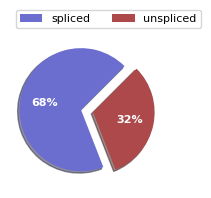

In [16]:
scv.pl.proportions(adata_dict['adata_s_u_800obs_300genes'])

<Axes: >

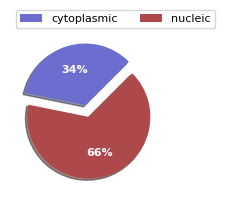

In [17]:
proportions_nuc_cyto(adata_random)

<Axes: >

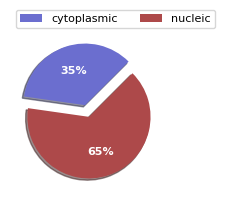

In [18]:
proportions_nuc_cyto(adata_dict['adata_n_c_800obs_300genes'])

# Preprocessing 

In [19]:
del adatas

In [20]:
prep_random = Preprocessing(adata_random,config_preprocessing)
adata_random = prep_random.preprocess_data()

computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [21]:
for key, adata in adata_dict.items():
    print(f'{key} is being preprocessed.')
    preprocessor = Preprocessing(adata,config_preprocessing)
    adata = preprocessor.preprocess_data()

adata_s_u_800obs_300genes is being preprocessed.
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
adata_n_c_800obs_300genes is being preprocessed.
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


# Velocity 

In [23]:
adata_random_800obs_300_genes_deterministic = adata_random.copy()
adata_random_800obs_300_genes_stochastic = adata_random.copy()

In [24]:
scv.tl.velocity(adata_random_800obs_300_genes_deterministic,mode='deterministic')
scv.tl.velocity(adata_random_800obs_300_genes_stochastic,mode='stochastic' )

computing velocities
The correlation threshold has been reduced to -0.6432.
Please be cautious when interpreting results.
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocities
The correlation threshold has been reduced to -0.6432.
Please be cautious when interpreting results.
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)


In [25]:
scv.tl.velocity_graph(adata_random_800obs_300_genes_deterministic)
scv.tl.velocity_graph(adata_random_800obs_300_genes_stochastic)

computing velocity graph (using 1/24 cores)
or disable the progress bar using `show_progress_bar=False`.
    finished (0:00:00) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity graph (using 1/24 cores)
    finished (0:00:00) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


In [26]:
velocity_computer = Velocities(adata_dict,config_velocity)
adata_dict_velocity = velocity_computer.compute_velocities()

Using device: cuda
deterministic velocity is being calculated.
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 12/24 cores)
    finished (0:00:16) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
stochastic velocity is being calculated.
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 12/24 cores)
    finished (0:00:01) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
recovering dynamics (using 8/24 cores)
    finished (0:00:19) --> added 
    'fit_pars', fitted parameters for splicing dynamics (adata.var)
dynamical velocity is being calculated.
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (u

# Save adatas 

In [27]:
adata_dict_velocity['adata_random_800obs_300_genes_deterministic']= adata_random_800obs_300_genes_deterministic
adata_dict_velocity['adata_random_800obs_300_genes_stochastic'] = adata_random_800obs_300_genes_stochastic

In [28]:
adata_dict_velocity = {f"{key}_n3": value for key, value in adata_dict_velocity.items()}

In [29]:
os.getcwd()

'c:\\Users\\OmerCagatayTalikaci\\Desktop\\github'

In [30]:
saving_path = os.path.join(os.getcwd(),'data','noise_3')

In [31]:
for d in adata_dict_velocity.keys():
    print(d)
    adata_dict_velocity[d].write(os.path.join(saving_path,d+'.h5ad'))

adata_s_u_800obs_300genes_deterministic_n3
adata_s_u_800obs_300genes_stochastic_n3
adata_s_u_800obs_300genes_dynamical_n3
adata_n_c_800obs_300genes_deterministic_n3
adata_n_c_800obs_300genes_stochastic_n3
adata_n_c_800obs_300genes_dynamical_n3
adata_random_800obs_300_genes_deterministic_n3
adata_random_800obs_300_genes_stochastic_n3
